# SUPPORT VECTOR REGRESSION
* Standart regresyonda (Linear Regression) amacımız, noktaların tam ortasından geçen ve hatayı en aza indiren o tek çizgiyi bulmaktır.
* SVR'da ise yaklaşım bir çizgi değil, **tünel** oluşturmaya çalışırız.
* SVR şunu der: Çizginin etrafına öyle bir tünel çizeyim ki, verilerin mümkün olduğunca çoğu tünel içinde kalsın.
* Bu noktada tünelin içindeki hataları görmezden geliriz.
* Tünelin dışında kalan noktalar ise bizim için kritik `destek vektörleridir.`

## NEDEN SVR KULLANILIR ?
* Veri setinde çok fazla outlier varsa SVR buna karşı daha dayanıklıdırç
* Veri karmaşıksa ve basit bir çizgiyle çözülemiyorsa çok güçlüdür.

## SVR NE ZAMAN KULLANILIR?
* Veri gürültülü ise
* Outlier varsa
* İlişki karmaşıksa


# Verilere göre mantıklı yol çizmek

## Linear Regression(Düz Çizgi)
* Basit ilişkileri yakalar ama eğri varsa kaçırır
* Gerçek hayata çoğu zaman yetmez

## Polynomial Regression (Eğri Çizgi)
* Düz yetmedi, eğri çizeyim
* Model değişir ama grafik eğri olur
* Fazla degree overfitting'e neden olur

## SVR + Kernel (Özellikle RBF)
* SVR her noktaya uymaz, bir tolerans aralığı (marjin) belirler ve ona göre çizer
**Kernel nedir ?**= Kernel, SVR'nin veriye nasıl bir şekil çizerek yaklaşacağını belirleyen yöntemdir.
Eğer veri düz bir çizgiyle çaıklanabiliyorsa farklı bir kernel kullanılır. Eğere veri karmaşık, eğri bir yapıdaysa başka bir kernel kullanılır. Yani kısaca kernel seçimi şunu belirler:
- Model düz bir çizgi mi çizecek?
- Eğrisel bir ilişki mi yakalayacak?
- Daha karmaşık desenleri mi öğrenecek ?

### Linear Kernel(SVR içinde)
* Düz tünel çizer.
### Polynomial Kernel
* Eğri tünel çizer.
* Örneğin yaş ile gelir ilişkisi. Gençken gelir düşük olabilir, orta yaşta artar bir yerden sonra sabitlenir.
veya ilaç dozu ile etki ilişkisi. Düşük dozda az etki, orta dozda istenen etki ve yüksek dozda yan etki gibi.
* Degree eğrinin karmaşıklığını belirler ve eğer degree çok yükselirse model veriyi öğrenmez ezberler. buna **overfitting** denir.
### RBF Kernel (Radial Basis Function)
* Verideki karmaşık ve doğrusal olmayan ilişkileri yakalamaya çalışır.
* Veri çok karmaşıksa başka bir boyuta taşıyor.
* RBF, bir noktanın tahminini yaparken, ona yakın olan veri noktalarına daha çok önem verir. Yani yakınlık kavramını çok önemser.
* RBF kernel'de önemli bir parametre vardır:`gamma`
* Gamma, tek bir veri noktasının etki alanını belirler. Düşük gamma, her noktanın etki alanını daha geniş alana yayar, model daha yumuşak olur.
* Yüksek gamma'da her noktanın etkisi dar alanda kalır. Model daha kıvrımlı ve hassas olur.    



# SVR'de ÖNEMLİ PARAMETRELER

## C Parametresi
* c, hatalara ne kadar ceza verileceğini belirler.
* küçük c değerinde model daha toleranslıdır, hataları çok büyütmez basit model olur.
* yüksek c'de model hataları azaltmak için çok çalışır. Bu modeli daha karmaşık hale getirebilir.
## Epsilon Parametresi
* Epsilon, tahmin çizgisinin etrafındaki kabul edilebilir hata bandıdır.
* Büyük epsilonda tolerans geniştir, küçük hatalar önemsenmez.
* Yüksek epsilon dar toleranslıdır, modeli hassas hale getirir.
## Gamma parametresi
* Özellikle RBF ve polynomial kernel'da önemlidir.
* **Düşük gamma** -> Daha yumuşak model
* **Yüksek gamma** -> Daha detaycı model


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

veri = pd.read_csv('maaslar.csv')
veri

,unvan,Egitim Seviyesi,maas
0,Cayci,1,2250
1,Sekreter,2,2500
2,Uzman Yardimcisi,3,3000
3,Uzman,4,4000
4,Proje Yoneticisi,5,5500
5,Sef,6,7500
6,Mudur,7,10000
7,Direktor,8,15000
8,C-level,9,25000
9,CEO,10,50000


In [8]:
x=veri.iloc[:,1:2]
y=veri.iloc[:,2:3]
X=x.values
Y= y.values



In [19]:
#verilerin ölçeklenmesi 
from sklearn.preprocessing import StandardScaler
sc1 = StandardScaler()
sc2 = StandardScaler()
x_scaled = sc1.fit_transform(X)
y_scaled = sc2.fit_transform(Y)


In [20]:
from sklearn.svm import SVR
svr_reg = SVR(kernel ='rbf',epsilon=0.5)
svr_reg.fit(x_scaled,y_scaled)

C:\Users\Görkem\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.5
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


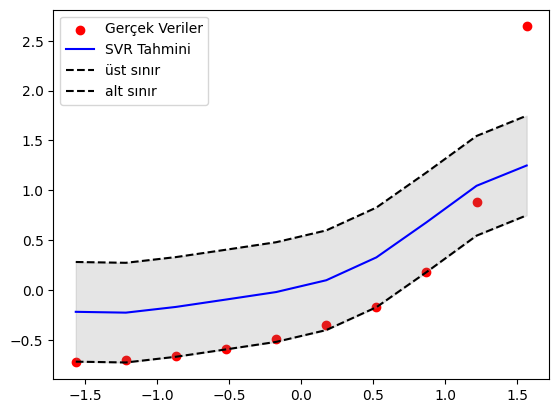

In [21]:
y_pred = svr_reg.predict(x_scaled)

plt.scatter(x_scaled,y_scaled,color='red',label='Gerçek Veriler')
plt.plot(x_scaled,y_pred,color='blue',label='SVR Tahmini')
epsilon = svr_reg.epsilon
plt.plot(x_scaled,y_pred + epsilon, color='black',linestyle='dashed',label='üst sınır')
plt.plot(x_scaled,y_pred - epsilon, color='black',linestyle='dashed',label='alt sınır')

plt.fill_between(x_scaled.ravel(),y_pred - epsilon, y_pred + epsilon, color='gray',alpha=0.2)
plt.legend()
plt.show()